# Imagix3D
## Results check

Here, we are going to check out the results of Imagix3D pipeline runs on the HPC cluster

**Setting the Correct Path**

In [1]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")

Changed to: C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package


### Loading the data
**Please Note:** The following approach for loading an Imagix3D pipeline object is only necessary (or does only work) if the pipeline ran on a **GPU** machine (i.e. *HPC Alpha*) with a **Unix** OS, and you want to <ins>investigate the results on a Windows PC</ins>. It uses a PyTorch patch to work around a CUDA deserialization problem that occurs on Windows machines.  

In [2]:
import os
import io
import signal
import torch
import autoencodix as acx

# Define path of the to-be-loaded results object
basepath = r"C:/chris/FU/Msc_Data_Science/Masterarbeit/hpc_pipelines/results"
results_folder = "gpu_synapse_64cube_250epochs_2026-06-12_20-52-49"
outpath = os.path.join(basepath, results_folder, "imagix3d.pkl")

# Compatibility fix for Linux-created pickle files.
# Windows does not define signal.SIGUSR1, but the pickle expects it.
if not hasattr(signal, "SIGUSR1"):
    signal.SIGUSR1 = 1 # the assigned value is arbitrary

# Save PyTorch's original internal tensor-storage loader.
_original_load_from_bytes = torch.storage._load_from_bytes

# Define a replacement loader that maps CUDA tensors to CPU.
def _load_from_bytes_cpu(b):
    return torch.load(io.BytesIO(b), map_location=torch.device("cpu"))

# Temporarily replace PyTorch's loader.
torch.storage._load_from_bytes = _load_from_bytes_cpu

try:
    imagix3d_loaded = acx.Imagix3D.load(outpath)
finally:
    # Restore PyTorch's original behavior.
    torch.storage._load_from_bytes = _original_load_from_bytes

Attempting to load a pipeline from C:/chris/FU/Msc_Data_Science/Masterarbeit/hpc_pipelines/results/gpu_synapse_64cube_250epochs_2026-06-12_20-52-49\imagix3d.pkl...
Pipeline object loaded successfully. Actual type: Imagix3D
Preprocessor loaded successfully.


### Print VAE Model Output

In [3]:
display(imagix3d_loaded.result.model)

VolumeVAEArchitecture(
  (_encoder): Sequential(
    (0): Conv3d(1, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv3d(32, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (3): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (6): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (9): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv3d(256, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (12): BatchNorm3d(256, eps=1e-05, mo

### Print Overview of Config Settings

In [4]:
import json
import pandas as pd
from IPython.display import display
from enum import Enum
from pathlib import Path

def make_json_safe(obj):
    """Recursively convert objects into JSON-friendly Python objects."""
    if isinstance(obj, Enum):
        return obj.value
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    return obj

def config_to_dict(config):
    """Convert Pydantic config object to a plain dictionary."""
    if hasattr(config, "model_dump"):  # Pydantic v2
        cfg = config.model_dump(mode="python")
    elif hasattr(config, "dict"):      # Pydantic v1
        cfg = config.dict()
    else:
        raise TypeError(f"Unsupported config type: {type(config)}")

    return make_json_safe(cfg)

cfg = config_to_dict(imagix3d_loaded.config)

print(json.dumps(cfg, indent=2, ensure_ascii=False))

{
  "data_config": {
    "data_info": {
      "IMG": {
        "file_path": "/data/horse/ws/baeuchl-imagix3d/data/medmnist/synapse3d/test",
        "data_type": "IMG",
        "scaling": "MINMAX",
        "filtering": "VAR",
        "sep": null,
        "extra_anno_file": null,
        "is_single_cell": false,
        "min_cells": 0.05,
        "min_genes": 0.02,
        "selected_layers": [
          "X"
        ],
        "is_X": false,
        "normalize_counts": true,
        "log_transform": false,
        "k_filter": null,
        "img_width_resize": 64,
        "img_height_resize": 64,
        "translate_direction": null,
        "pretrain_epochs": null
      },
      "ANNO": {
        "file_path": "/data/horse/ws/baeuchl-imagix3d/data/medmnist/synapse3d/test_metadata.csv",
        "data_type": "ANNOTATION",
        "scaling": "NOTSET",
        "filtering": "VAR",
        "sep": null,
        "extra_anno_file": null,
        "is_single_cell": false,
        "min_cells": 0.05,
  

### The Evaluate Step

Here, we use the `latent space` and compare it to other dimensionality reduction techniques like PCA, UMAP, or a random baseline.  
In the basic case, you can specify a column in your annotation data to use for a machine learning task, e.g., training a classifier on disease state or cancer type. We then use the representations (latent space, UMAP, etc.) to train this classifier/regressor.  
You have many options to customize this step for your needs, such as passing a scikit-learn model and defining evaluation metrics. Please refer to [3] for a complete guide.

[3] Tutorials/DeepDives/EvaluateTutorial.ipynb

Perform ML task with feature df: PCA
PCA
Perform ML task for target parameter: group
Perform ML task with feature df: UMAP
UMAP
Perform ML task for target parameter: group
Perform ML task with feature df: RandomFeature
RandomFeature_R1
Perform ML task for target parameter: group
RandomFeature_R2
Perform ML task for target parameter: group
RandomFeature_R3
Perform ML task for target parameter: group
RandomFeature_R4
Perform ML task for target parameter: group
RandomFeature_R5
Perform ML task for target parameter: group
Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: group
CPU times: total: 5min 19s
Wall time: 4min 53s


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VolumeVAEArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._image_dataset.ImageDataset object at 0x00000219F98B7410>, valid=<autoencodix.data._image_dataset.ImageDataset object at 0x0000021989FA4190>, test=<autoencodix.data._image_dataset.ImageDataset object at 0x00000219F9ABAB50>)
new_datasets: DatasetContainer(train=None, valid=None, test=None)
adata_latent: AnnData object with n_obs × n_vars = 71 × 64
    uns: 'var_names'
final_recons

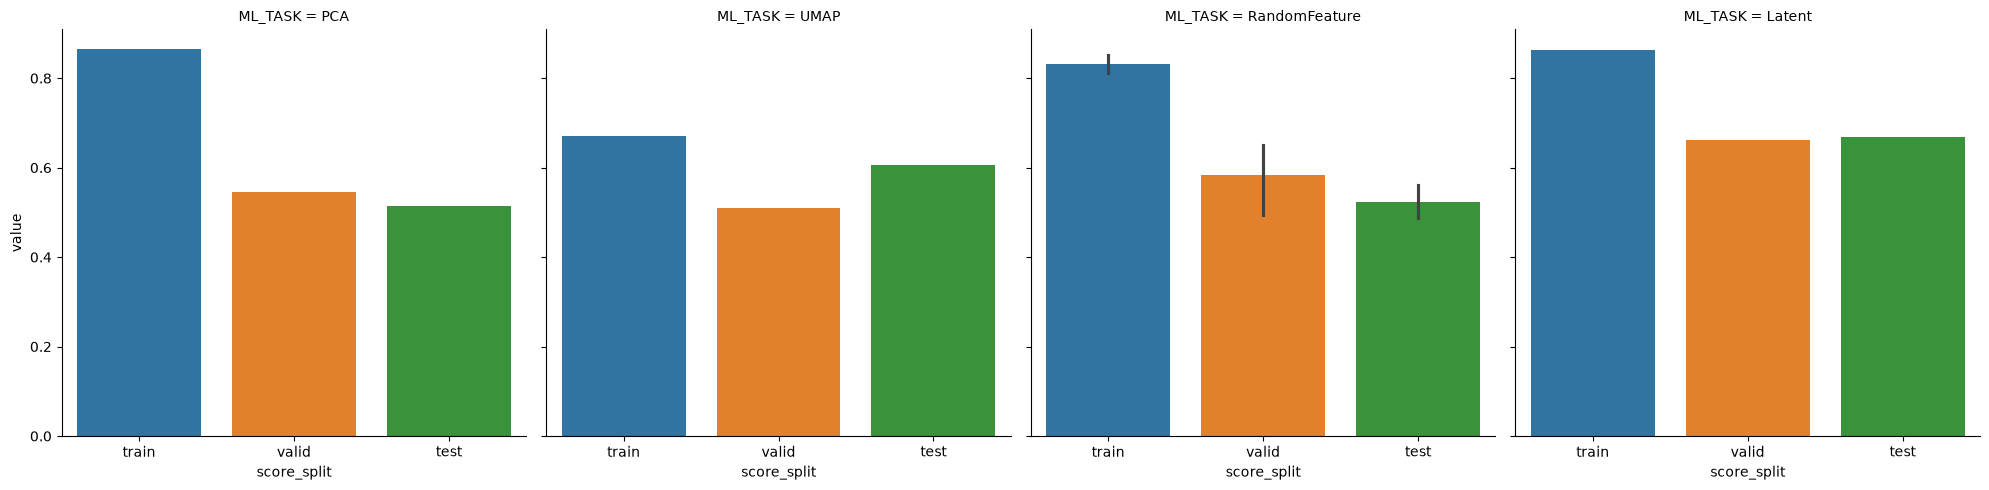

In [5]:
%%time
# In our annotation file, we have a column called "group"
# that refers to the age group of our subjects.
imagix3d_loaded.evaluate(
    params=["group"],
    reference_methods=["PCA", "UMAP", "RandomFeature"]  #TSNE
)

## IF RandomFeature does not converge, use this variant:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# clf = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(max_iter=2000)
# )

# imagix3d_loaded.evaluate(
#     params=["group"],
#     reference_methods=["PCA", "UMAP", "RandomFeature"],
#     ml_model_class=clf
# )

Showing plot for ML algorithm: LogisticRegression


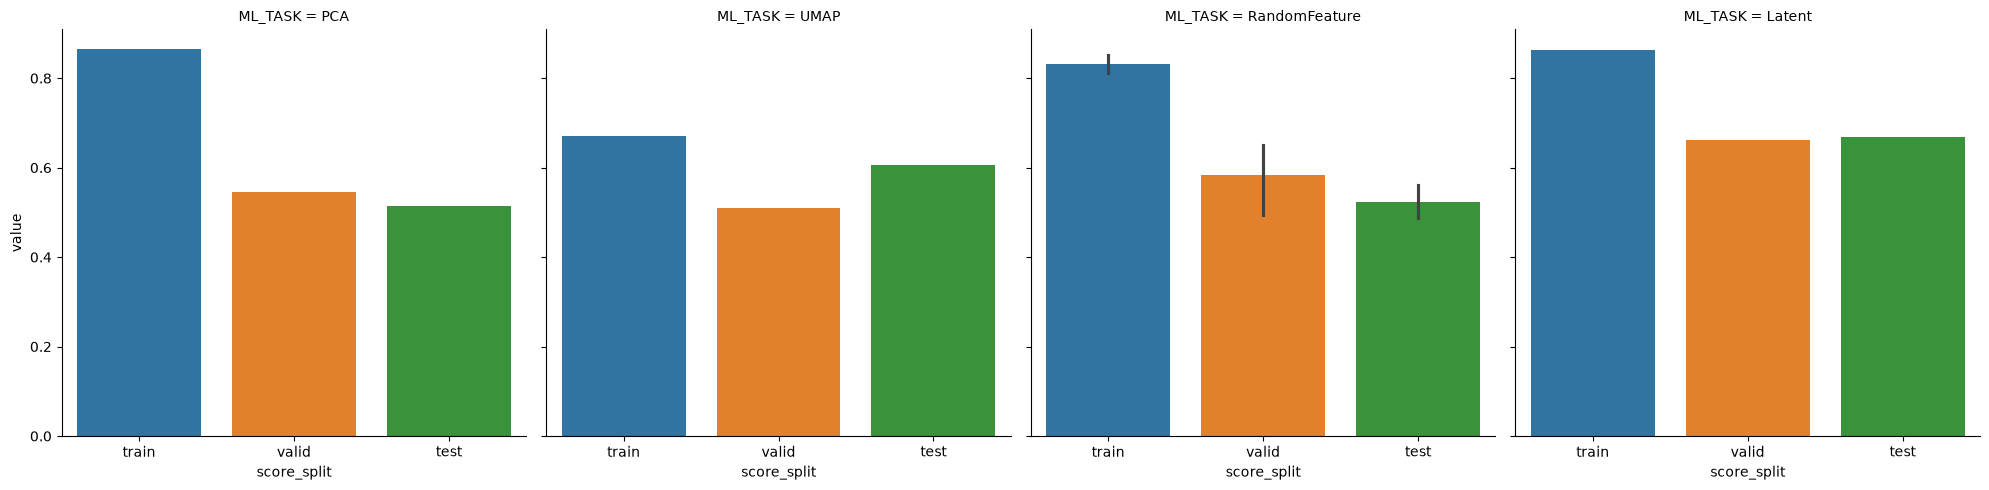

In [6]:
# Next, we can visualize the evaluation output with:
import matplotlib.pyplot as plt
plt.close("all")
imagix3d_loaded.visualizer.show_evaluation(
    param="group",
    metric="roc_auc_ovo",
)

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

latent_df = imagix3d_loaded.result.get_latent_df(epoch=-1, split="test")

print(latent_df.shape)
display(latent_df.head())

n_samples = latent_df.shape[0]
perplexity = min(30, max(2, (n_samples - 1) // 3))

X = StandardScaler().fit_transform(latent_df)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=1,
    init="pca",
    learning_rate="auto"
)

tsne_arr = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    tsne_arr,
    index=latent_df.index,
    columns=["TSNE1", "TSNE2"]
)

display(tsne_df.head())

In [ ]:
meta = imagix3d_loaded._datasets.test.metadata

plot_df = tsne_df.join(meta[["group"]], how="left")

display(plot_df.head())

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

for group, sub in plot_df.groupby("group"):
    ax.scatter(sub["TSNE1"], sub["TSNE2"], label=group, alpha=0.8)

ax.set_xlabel("TSNE1")
ax.set_ylabel("TSNE2")
ax.legend(title="group")
plt.show()

In [ ]:
n_samples = latent_df.shape[0]

# t-SNE perplexity must be smaller than the number of samples.
perplexity = min(30, max(2, (n_samples - 1) // 3))

X = StandardScaler().fit_transform(latent_df)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=1,
    init="pca",
    learning_rate="auto"
)

tsne_arr = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    tsne_arr,
    index=latent_df.index,
    columns=["TSNE1", "TSNE2"]
)

display(tsne_df.head())

In [7]:
display(imagix3d_loaded.result.embedding_evaluation)

,score_split,CLINIC_PARAM,metric,value,ML_ALG,ML_TYPE,ML_TASK,ML_SUBTASK
0,train,group,roc_auc_ovo,0.865922,LogisticRegression,classification,PCA,PCA
1,valid,group,roc_auc_ovo,0.545455,LogisticRegression,classification,PCA,PCA
2,test,group,roc_auc_ovo,0.514286,LogisticRegression,classification,PCA,PCA
0,train,group,roc_auc_ovo,0.670558,LogisticRegression,classification,UMAP,UMAP
1,valid,group,roc_auc_ovo,0.510490,LogisticRegression,classification,UMAP,UMAP
2,test,group,roc_auc_ovo,0.605952,LogisticRegression,classification,UMAP,UMAP
0,train,group,roc_auc_ovo,0.860335,LogisticRegression,classification,RandomFeature,RandomFeature_R1
1,valid,group,roc_auc_ovo,0.646853,LogisticRegression,classification,RandomFeature,RandomFeature_R1
2,test,group,roc_auc_ovo,0.464286,LogisticRegression,classification,RandomFeature,RandomFeature_R1
0,train,group,roc_auc_ovo,0.819561,LogisticRegression,classification,RandomFeature,RandomFeature_R2


In [8]:
from IPython.display import display

result = imagix3d_loaded.result
# Get the reconstructions of the test split
rec_test = result.reconstructions.get(split="test")

# Get sample_ids for this latent space
sample_ids = result.sample_ids.get(split="test")

# A utility wrapper to get the latent space as a DataFrame
display(result.get_latent_df(epoch=-1, split="test"))
display(result.mus.get(split="test", epoch=-1))
display(result.sigmas.get(split="test", epoch=-1))
display(result.sub_losses.get(key="var_loss"))

,LatDim_0,LatDim_1,LatDim_2,LatDim_3,LatDim_4,LatDim_5,LatDim_6,LatDim_7,LatDim_8,LatDim_9,...,LatDim_54,LatDim_55,LatDim_56,LatDim_57,LatDim_58,LatDim_59,LatDim_60,LatDim_61,LatDim_62,LatDim_63
test_00004,2.377625,-0.166747,2.902421,-0.063298,1.808841,-1.549432,0.833730,-1.839246,-1.285689,1.556002,...,-1.205524,3.812113,0.969653,1.138028,-0.711721,1.055009,1.280916,-1.550601,1.781887,-1.259960
test_00293,1.649209,3.859961,-0.534028,-1.041719,1.729590,-0.628056,-0.696333,-0.922074,-0.803365,-0.392540,...,1.177657,1.348790,1.275680,2.916405,-1.603564,0.407888,-2.973974,0.339331,-1.275696,5.030659
test_00059,1.141211,4.493797,-0.738511,-0.646897,-1.405503,-0.098304,0.761515,0.832121,0.304219,1.276525,...,-0.697047,0.726863,-1.042479,0.992061,-1.087286,-0.936885,5.027486,-0.201513,-0.143155,-0.033308
test_00070,1.230288,-0.800279,0.287737,-0.645893,-0.231835,-2.206905,2.252522,-0.030731,-0.008552,-1.165551,...,0.150860,-0.207101,3.252727,0.227343,0.984703,0.227641,-0.233802,0.796191,0.519850,5.290545
test_00308,0.962926,0.690180,-0.812061,-0.479223,3.661473,-0.560553,2.313459,-0.213479,-0.524888,-1.148902,...,0.854267,0.960137,0.392674,2.700984,-2.228018,3.217492,1.688123,1.174012,-0.264872,-1.738261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_00087,0.993175,5.738061,1.788473,-0.098775,0.939780,0.605829,1.143371,-0.404313,1.357825,2.668570,...,-0.209910,-0.990736,-1.195877,-1.165494,-0.016628,-0.410123,3.626294,-0.574523,0.885653,-0.898718
test_00164,0.370683,0.136746,1.114473,-0.734875,-0.059053,-1.106766,0.479351,-0.142264,0.046173,4.764025,...,1.089515,-0.916733,2.381601,-0.884062,0.357459,-0.455258,6.672477,0.191396,-1.073171,-1.039027
test_00095,2.275083,-0.075325,-1.251933,-1.005640,-0.032258,0.736681,2.740321,4.083688,-2.337839,1.298025,...,-0.746032,-0.999177,1.196820,2.500793,1.184891,0.369700,-0.029473,-0.055037,-1.639366,0.727374
test_00167,0.455630,0.806439,-0.798253,-0.591227,0.056834,0.080676,-2.442421,1.746594,3.883833,-2.200759,...,-0.325115,2.348783,2.567822,1.325890,1.366709,-1.083451,-0.471812,-0.916354,-0.924785,-0.265165


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.95645684, 1.9710653 , 0.        , ..., 0.        , 0.        ,
        3.1804276 ],
       [0.        , 4.1964626 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.689891  ],
       [0.        , 0.        , 0.        , ..., 0.78712523, 0.        ,
        0.        ],
       [1.552863  , 0.        , 0.        , ..., 0.        , 0.        ,
        0.75199413]], dtype=float32)

array([[0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       ...,
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1]], dtype=float32)

TrainingDynamics()

### Visualize the reconstructions as images


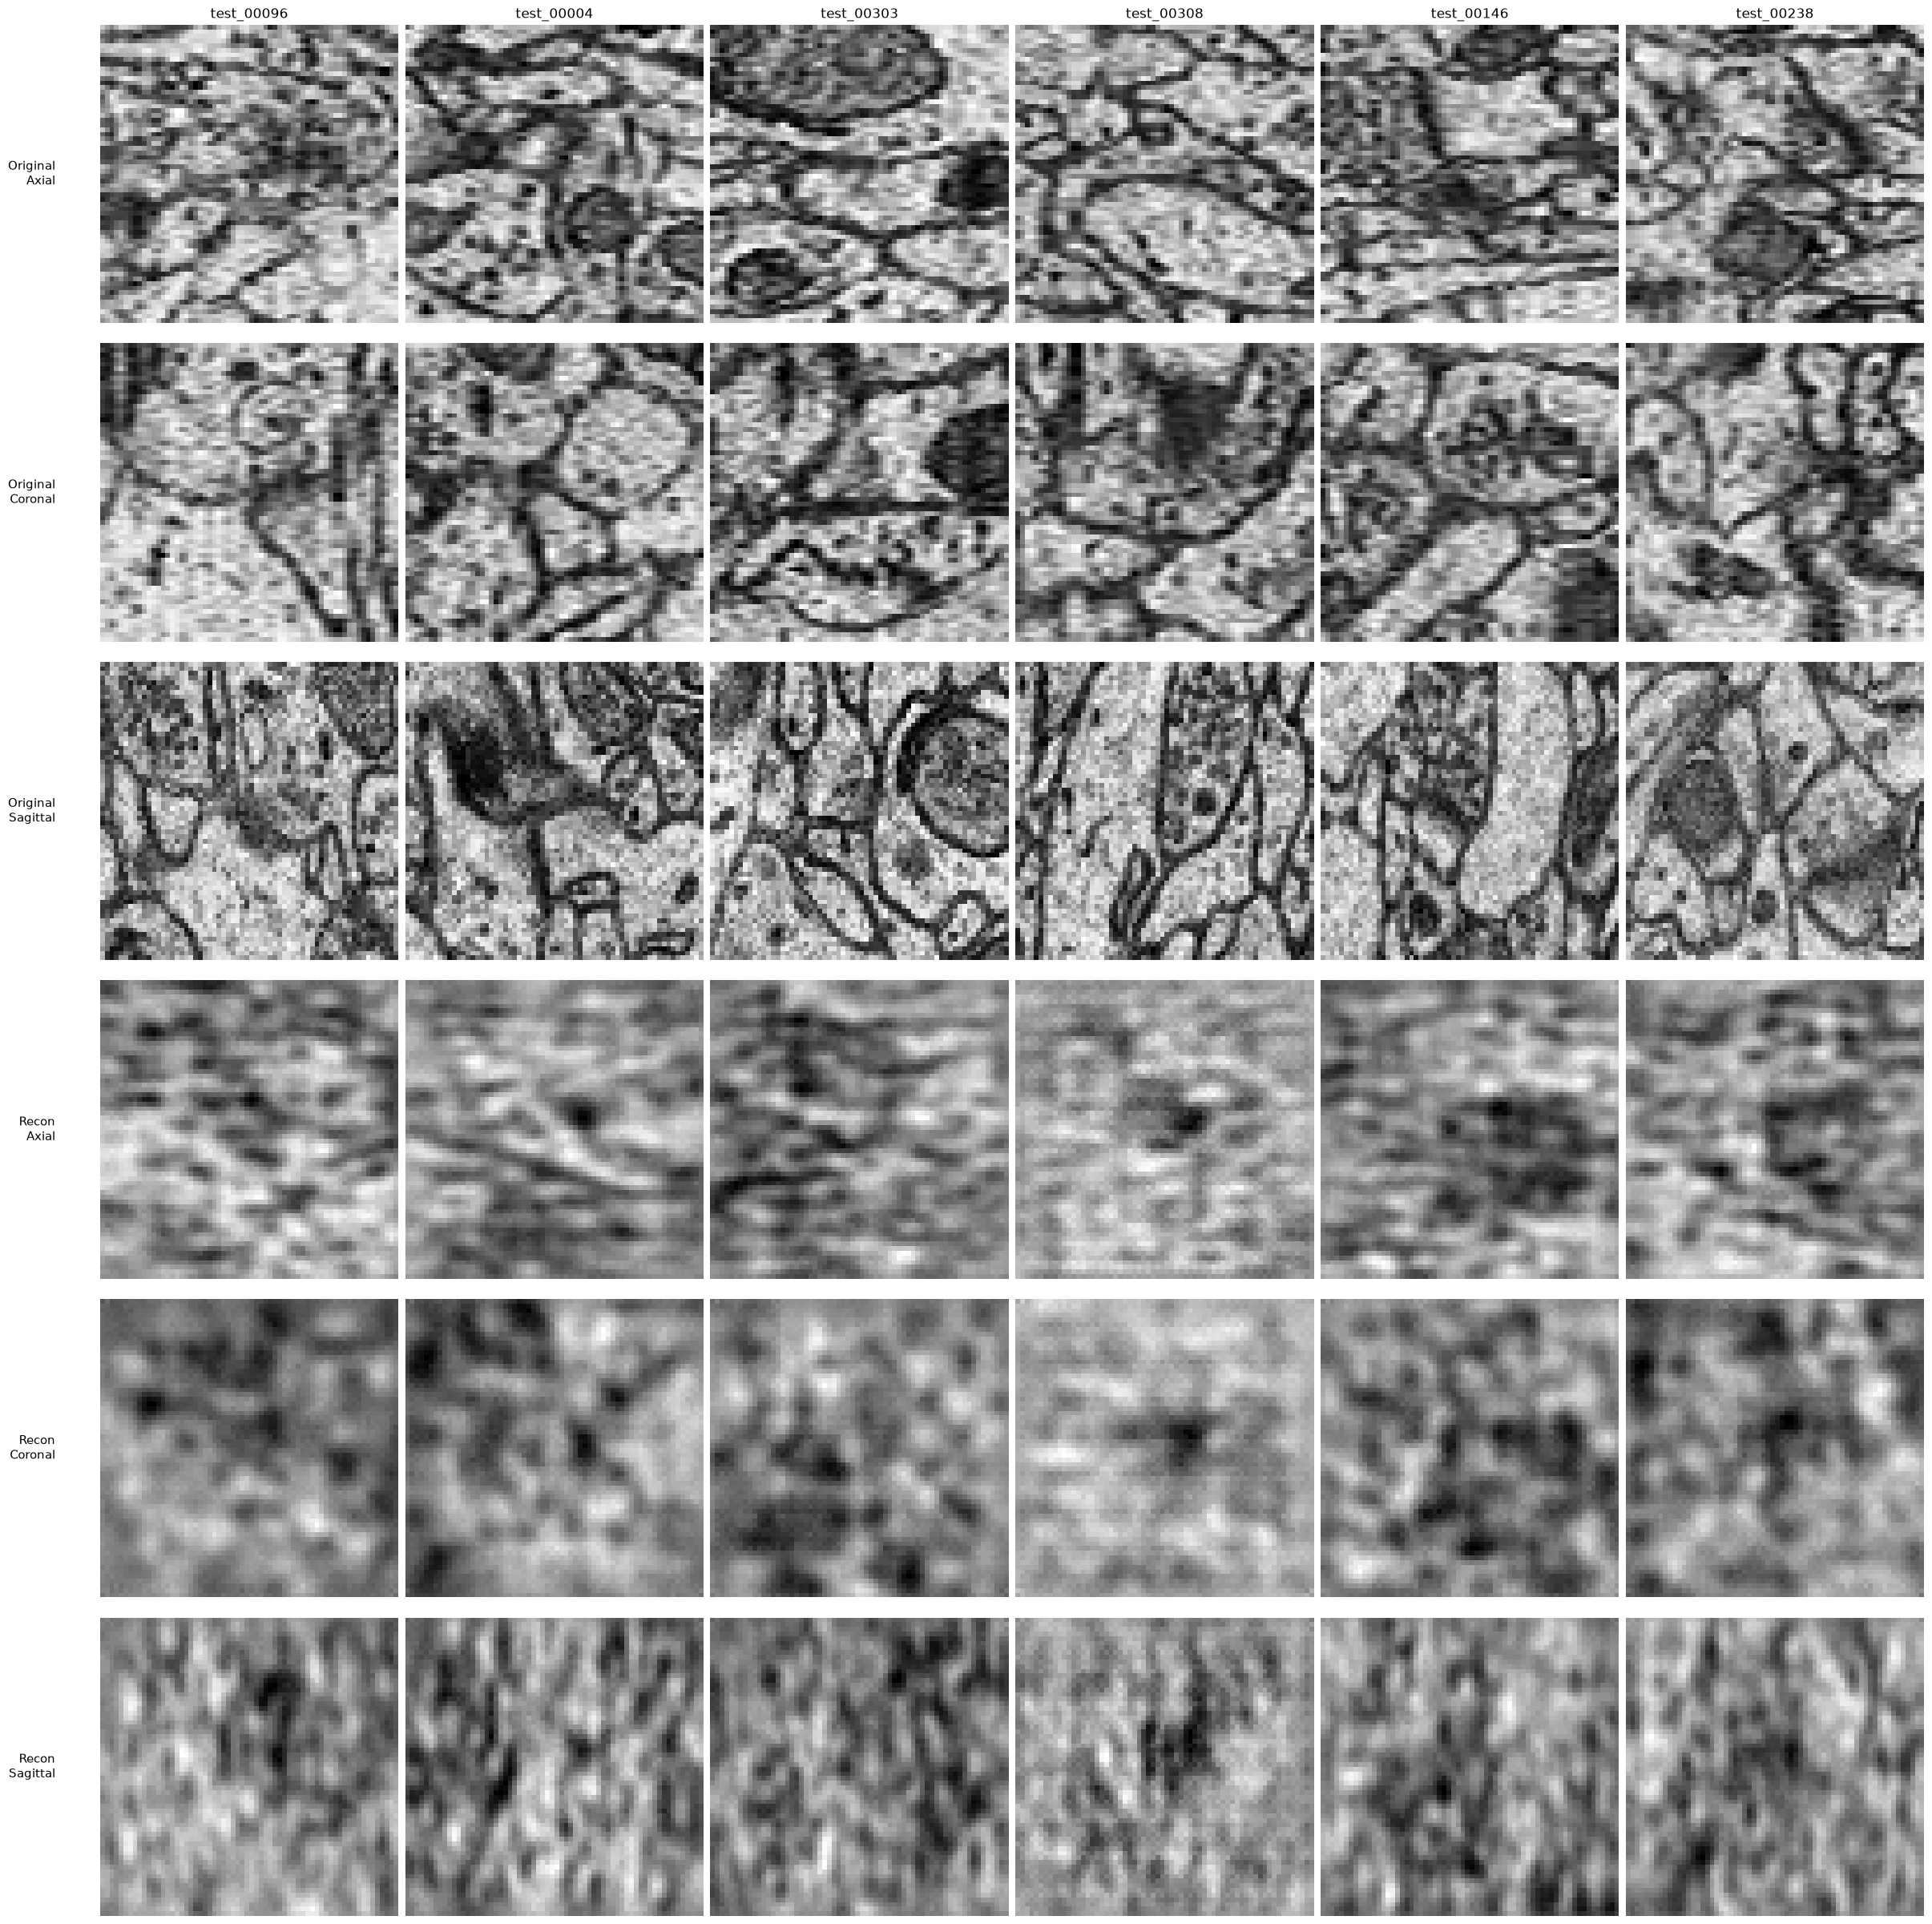

In [9]:
imagix3d_loaded.visualizer.show_image_recon_grid(result=imagix3d_loaded.result, n_samples=6)

### Visualize Losses and Latent Spaces

Creating plots ...


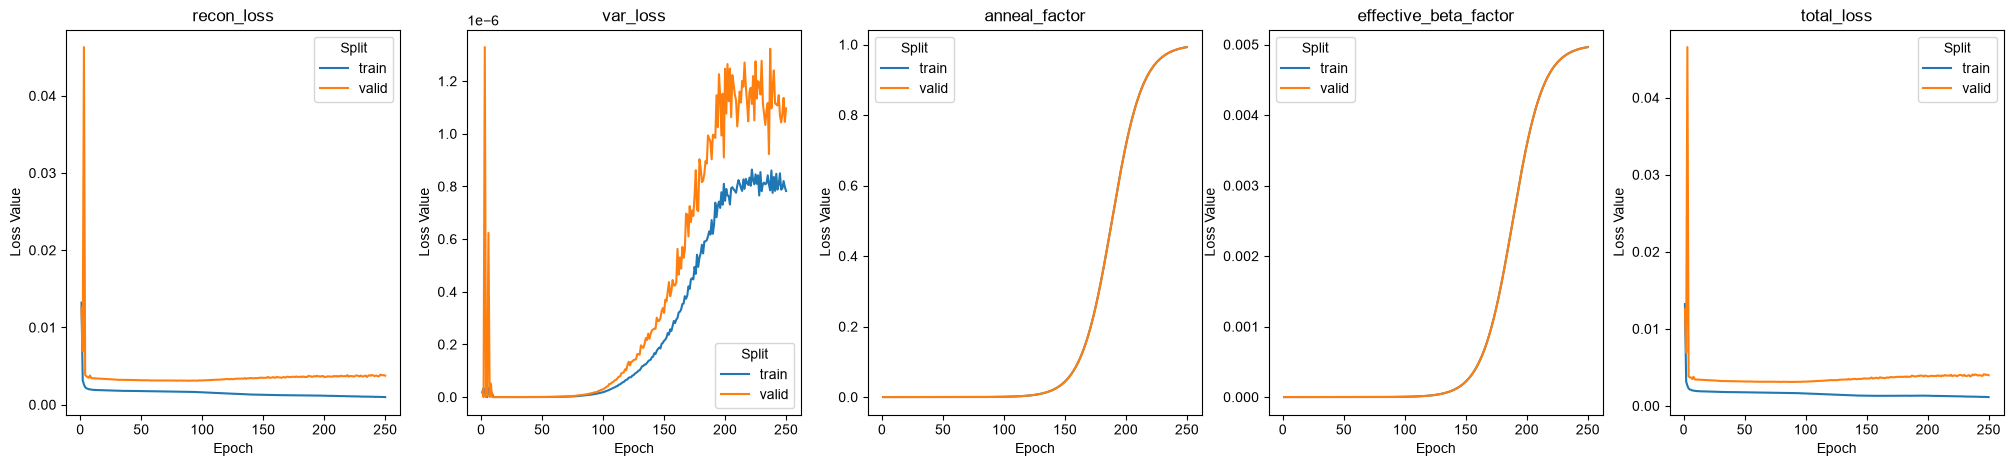

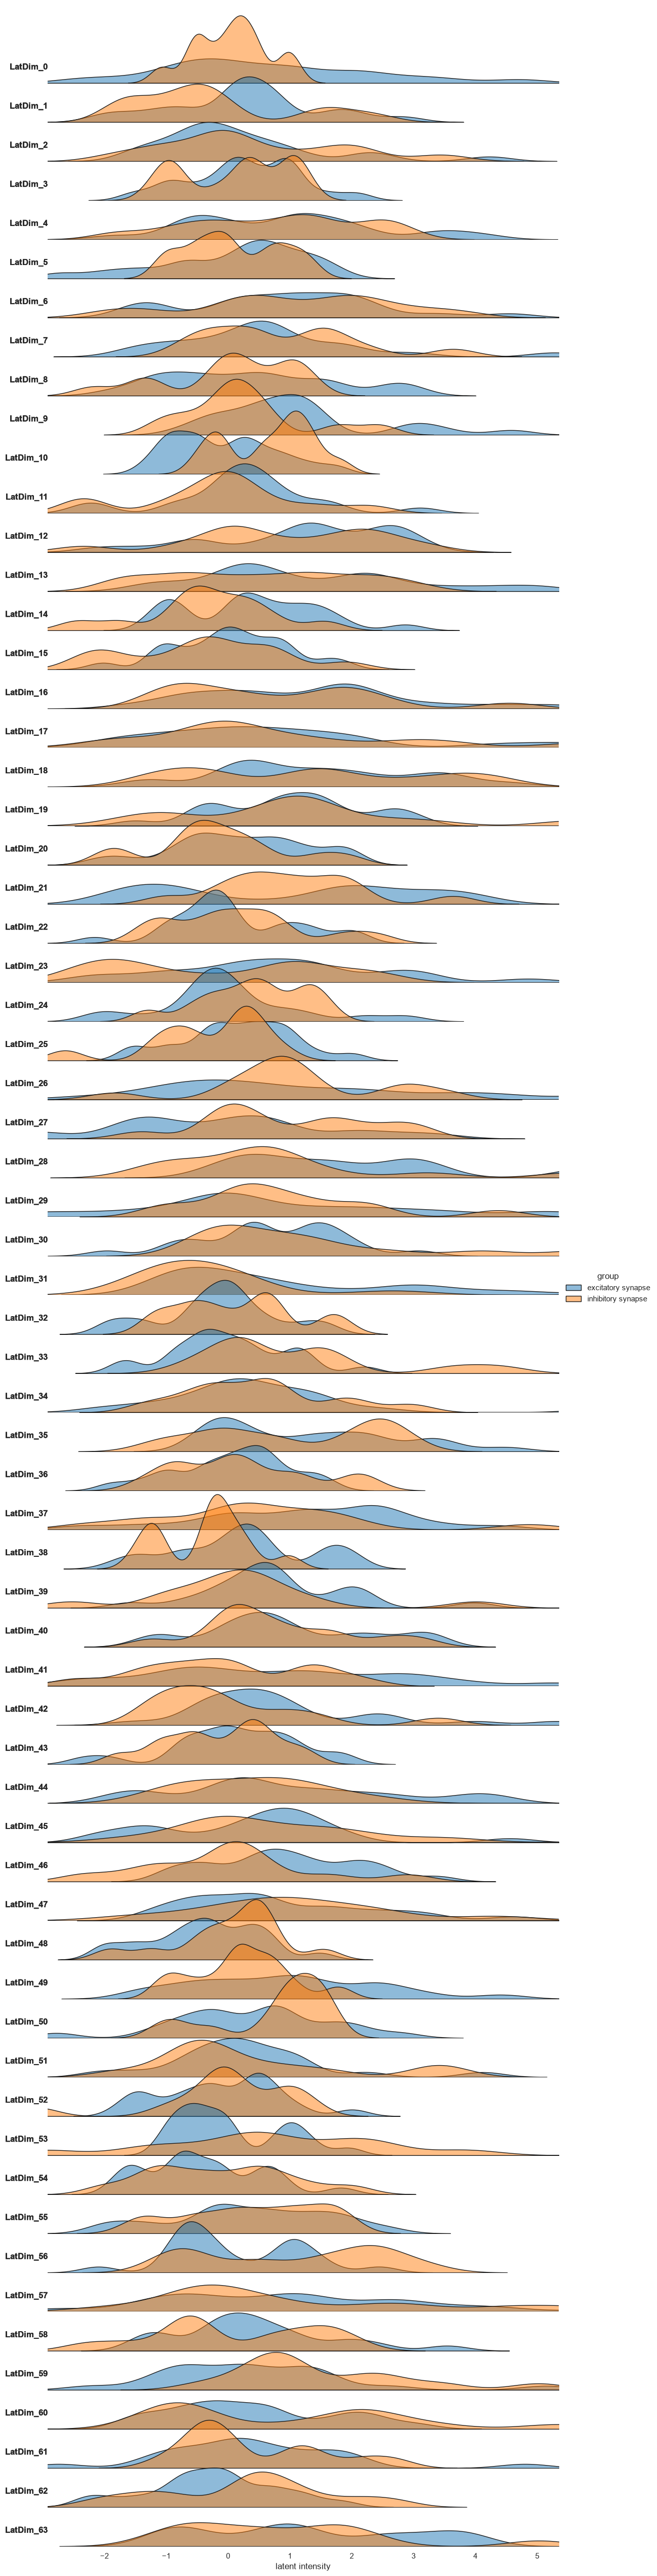

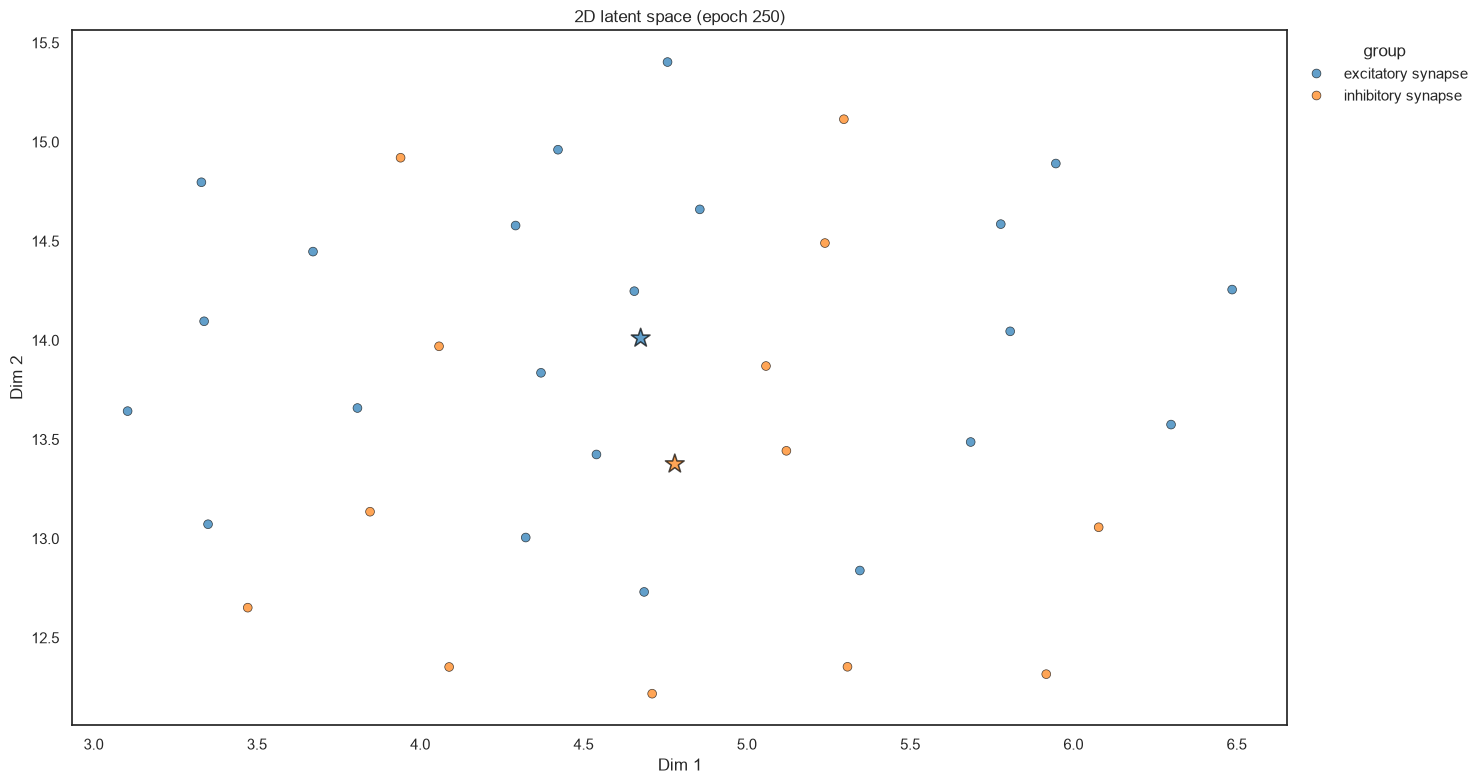

In [13]:
imagix3d_loaded.show_result(
    params=["group"],
    split="valid"
)

In [14]:
import inspect
print(imagix3d_loaded.show_result)
print(inspect.getfile(imagix3d_loaded.show_result))
print(inspect.getsourcelines(imagix3d_loaded.show_result)[1])

<bound method BasePipeline.show_result of <autoencodix.imagix3d.Imagix3D object at 0x00000219A596CB10>>
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\base\_base_pipeline.py
983


In [15]:
latest_train = imagix3d_loaded.result.get_latent_df(epoch=-1, split="train")
latest_valid = imagix3d_loaded.result.get_latent_df(epoch=-1, split="valid")
test_latent = imagix3d_loaded.result.get_latent_df(epoch=-1, split="test")

print("train:", latest_train.shape)
print("valid:", latest_valid.shape)
print("test:", test_latent.shape)

display(latest_train.iloc[:, :5].head())

train: (246, 64)
valid: (35, 64)
test: (71, 64)


,LatDim_0,LatDim_1,LatDim_2,LatDim_3,LatDim_4
test_00012,4.911875,0.457877,-0.877816,0.062343,-1.143177
test_00256,0.092095,1.359227,-0.289304,-0.582145,1.473312
test_00111,0.583320,1.850600,0.118664,1.518216,1.253434
test_00206,-0.702967,0.095039,-1.808833,0.918571,2.949615
test_00243,0.920444,0.468988,0.965905,-1.583960,4.060807


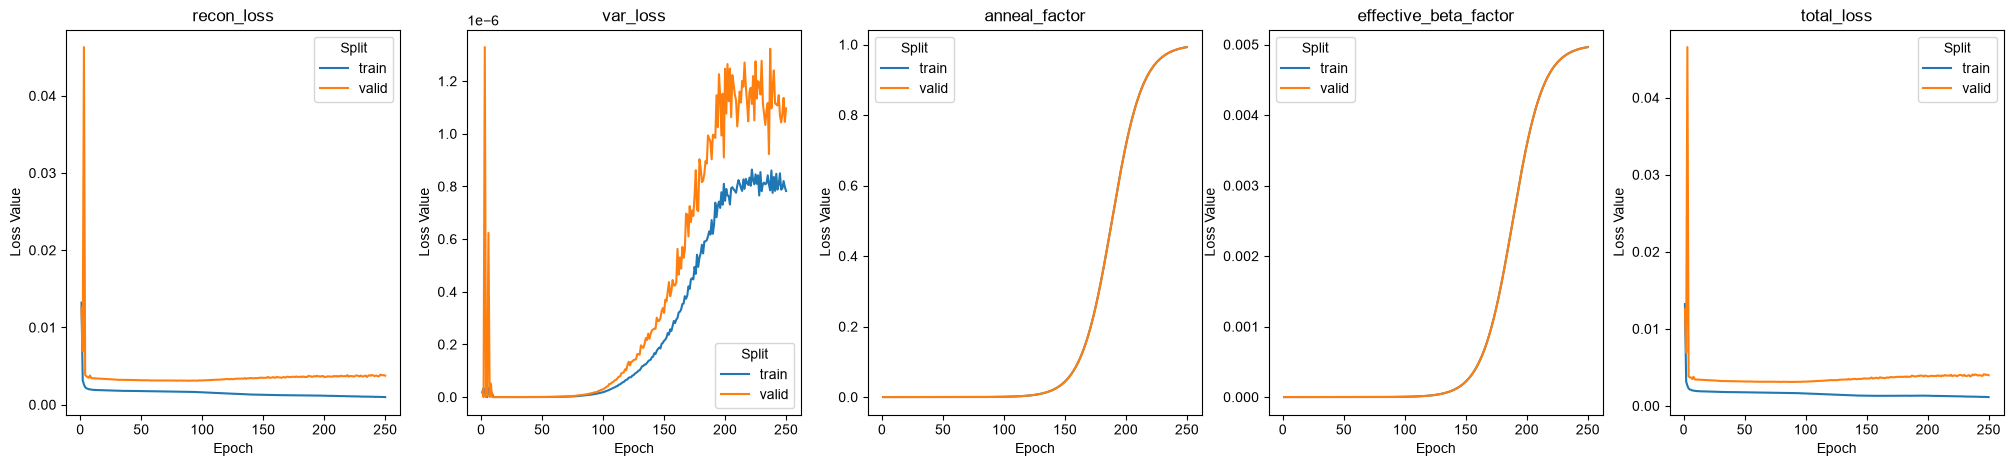

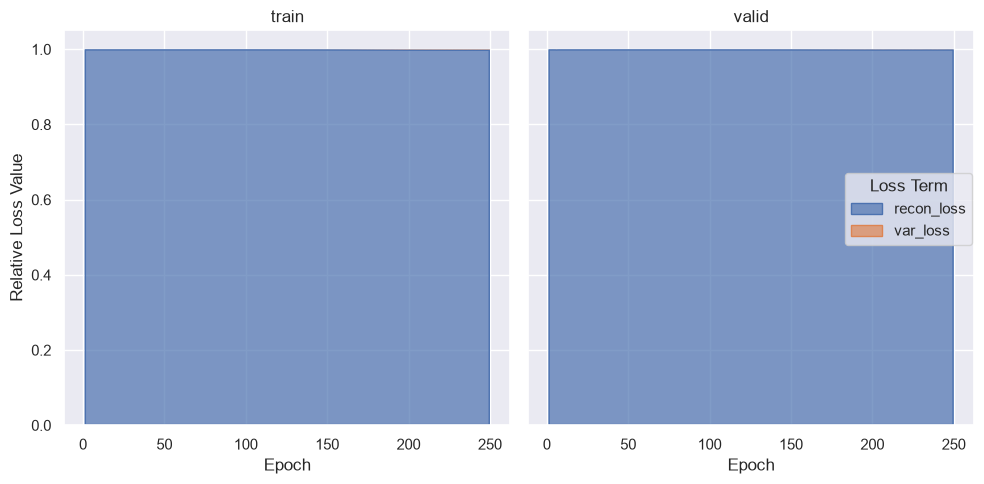

In [16]:
fig_loss_abs = imagix3d_loaded.visualizer.show_loss(plot_type="absolute") # Displays all loss components and factors over epochs
fig_loss_rel = imagix3d_loaded.visualizer.show_loss(plot_type="relative") # Displays contribution of loss components to total loss over epochs

In [17]:
import inspect
import pandas as pd

methods = []

for name, obj in inspect.getmembers(imagix3d_loaded.visualizer, predicate=inspect.ismethod):
    if name.startswith("_"):
        continue

    try:
        source_file = inspect.getfile(obj)
    except TypeError:
        source_file = None

    try:
        signature = str(inspect.signature(obj))
    except ValueError:
        signature = ""

    doc = inspect.getdoc(obj)
    first_doc_line = doc.split("\n")[0] if doc else ""

    methods.append({
        "method": name,
        "signature": signature,
        "defined_in": source_file,
        "doc": first_doc_line,
    })

method_table = pd.DataFrame(methods)
display(method_table)

,method,signature,defined_in,doc
0,save_plots,"(path: str, which: Union[str, list] = 'all', f...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Save specified plots to the given path in the ...
1,show_evaluation,"(param: str, metric: str, ml_alg: Optional[str...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Displays the evaluation plot for a specific cl...
2,show_image_recon_grid,"(result: autoencodix.utils._result.Result, n_s...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,
3,show_latent_space,"(result: autoencodix.utils._result.Result, plo...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Visualizes the latent space of the given resul...
4,show_loss,(plot_type: str = 'absolute') -> None,C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Display the loss plot.
5,show_weights,() -> None,C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Display the model weights plot if it exists in...
6,visualize,"(result: autoencodix.utils._result.Result, con...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,


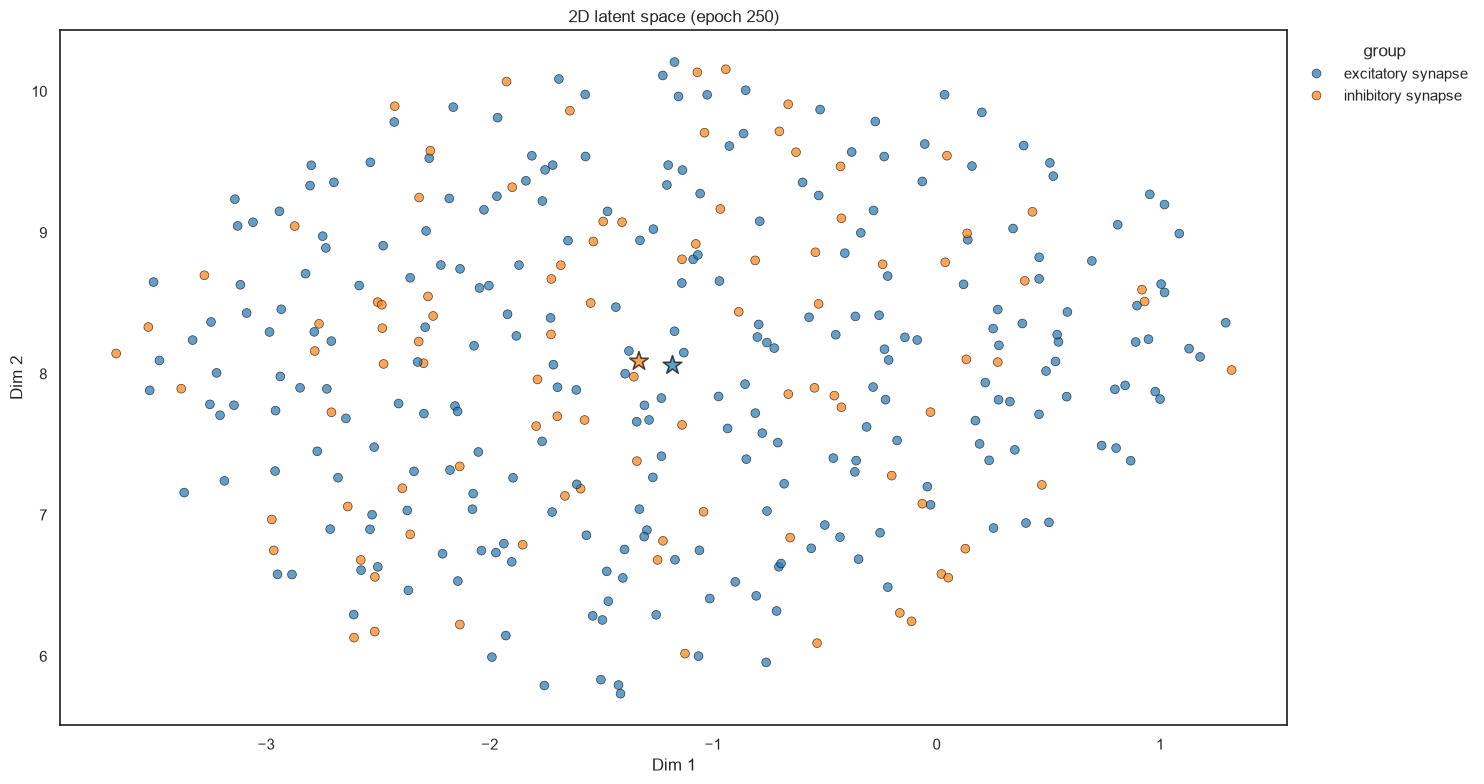

In [18]:
params = ["group"] # Specify metadata parameters to color/label the plots

fig_latent_2D = imagix3d_loaded.visualizer.show_latent_space(result=result, plot_type="2D-scatter", param=params)
#fig_latent_ridge = imagix3d_loaded.visualizer.show_latent_space(result=result, plot_type="Ridgeline", param=params)
#fig_latent_clustermap = imagix3d_loaded.visualizer.show_latent_space(result=result, plot_type="Clustermap", param=params)

C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage ca

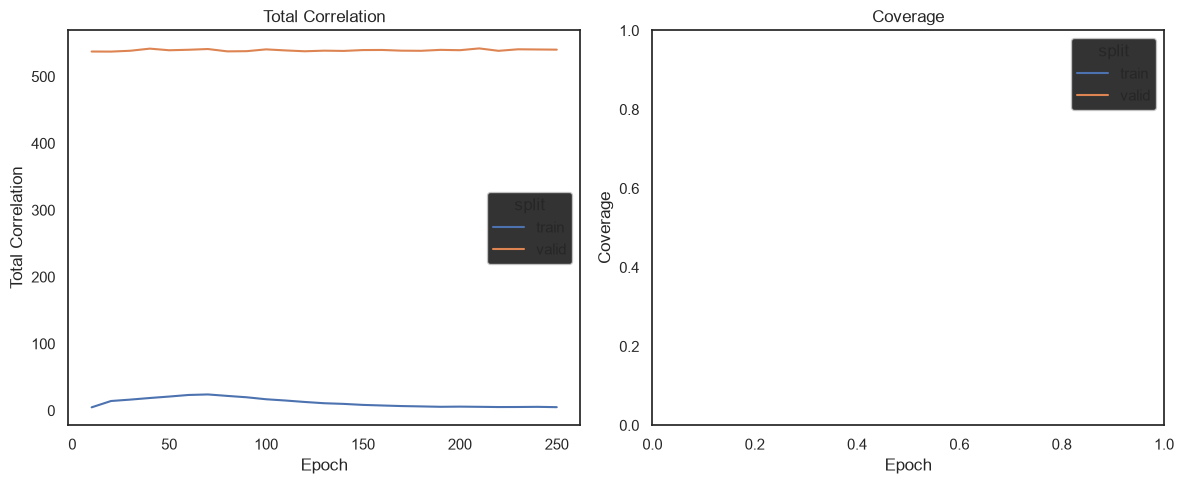

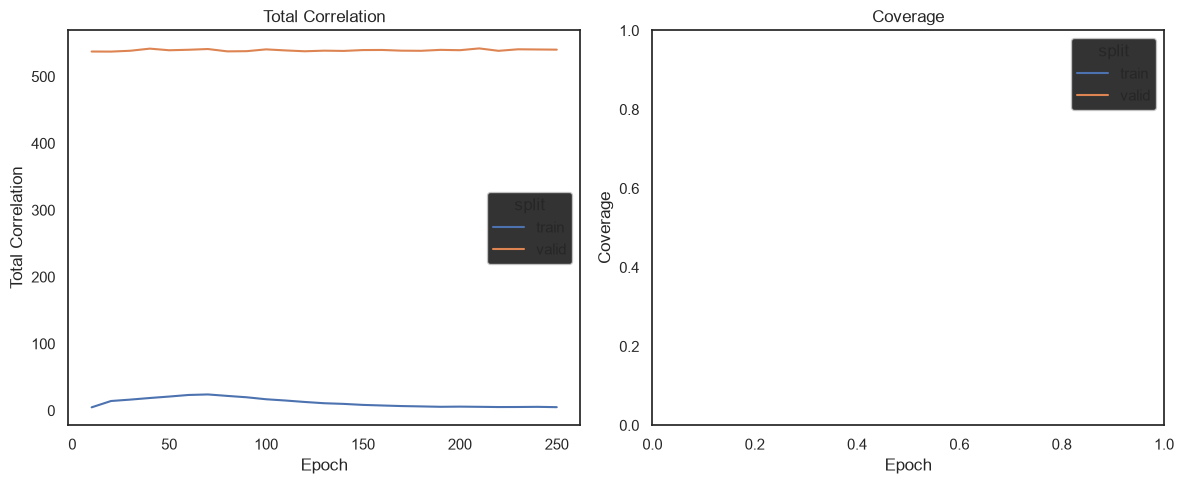

In [19]:
# To increase resolution over epochs, set the config parameter 'checkpoint_interval=1' before training
fig_latent_cov_tc = imagix3d_loaded.visualizer.show_latent_space(result=result, plot_type="Coverage-Correlation")
# TODO Coverage calculation fails for small valid split

C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage calculation fails since combination of sample size and latent dimension results in less than 2 bins.
  warnings.warn(
C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\visualize\_general_visualizer.py:902: UserWarning: Coverage ca

,epoch,split,total_correlation,coverage
0,10,train,4.809643,NaN
1,10,valid,537.364011,NaN
2,20,train,14.270387,NaN
3,20,valid,537.251178,NaN
4,30,train,16.372621,NaN


,epoch,split,total_correlation,coverage
45,230,valid,540.703290,NaN
46,240,train,5.529147,NaN
47,240,valid,540.424052,NaN
48,250,train,5.054113,NaN
49,250,valid,540.168385,NaN


(50, 4)


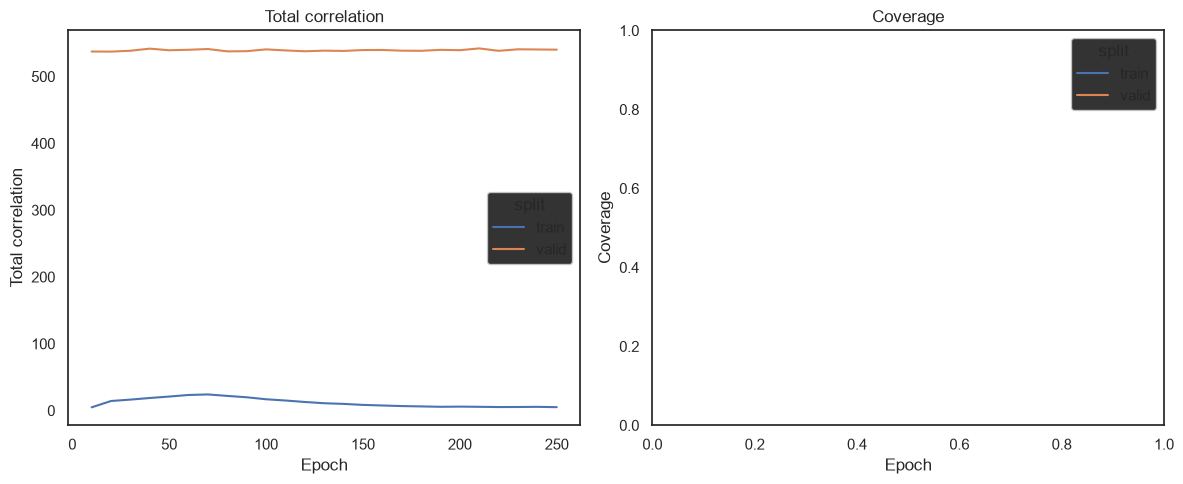

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

result = imagix3d_loaded.result
vis = imagix3d_loaded.visualizer

stored_epochs = sorted(
    e for e in result.latentspaces._data.keys()
    if e != -1
)

rows = []

for epoch in stored_epochs:
    for split in ["train", "valid"]:
        latent_df = result.get_latent_df(epoch=epoch, split=split)

        if latent_df.empty:
            continue

        tc = vis._total_correlation(latent_df)
        cov = vis._coverage_calc(latent_df)

        rows.append({
            "epoch": epoch + 1,   # display as human-counted epoch
            "split": split,
            "total_correlation": tc,
            "coverage": cov,
        })

df_metrics = pd.DataFrame(rows)

display(df_metrics.head())
display(df_metrics.tail())
print(df_metrics.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="total_correlation",
    hue="split",
    ax=axes[0],
)
axes[0].set_title("Total correlation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total correlation")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage",
    hue="split",
    ax=axes[1],
)
axes[1].set_title("Coverage")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Coverage")

plt.tight_layout()
plt.show()

In [ ]:
for key in imagix3d_loaded.visualizer.plots.keys():
    print(key)

In [21]:

vis = imagix3d_loaded.visualizer
res = imagix3d_loaded.result
cfg = imagix3d_loaded.config

In [ ]:
imagix3d_loaded.show_result(
    split="all",
    params=["group"]
)

In [ ]:
imagix3d_loaded.show_result(
    split="train",
    params=["group"]
)

imagix3d_loaded.show_result(
    split="valid",
    params=["group"]
)

imagix3d_loaded.show_result(
    split="test",
    params=["group"]
)

In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="2D-scatter",
    labels=None,
    focus_labels=None,
    param=["group"],
    epoch=None,
    split="all",
    n_downsample=10000,
)

In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="2D-scatter",
    labels=None,
    focus_labels=None,
    param=["group"],
    epoch=249,
    split="all",
    n_downsample=None,
)


In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="2D-scatter",
    labels=None,
    focus_labels=None,
    param=["group"],
    epoch=None,
    split="test",
    n_downsample=None,
)

In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="Coverage-Correlation",
    labels=None,
    focus_labels=None,
    param=None,
    epoch=None,
    split="all",
    n_downsample=10000,
)

In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="Clustermap",
    labels=None,
    focus_labels=None,
    param=["group"],
    epoch=None,
    split="all",
    n_downsample=10000,
)

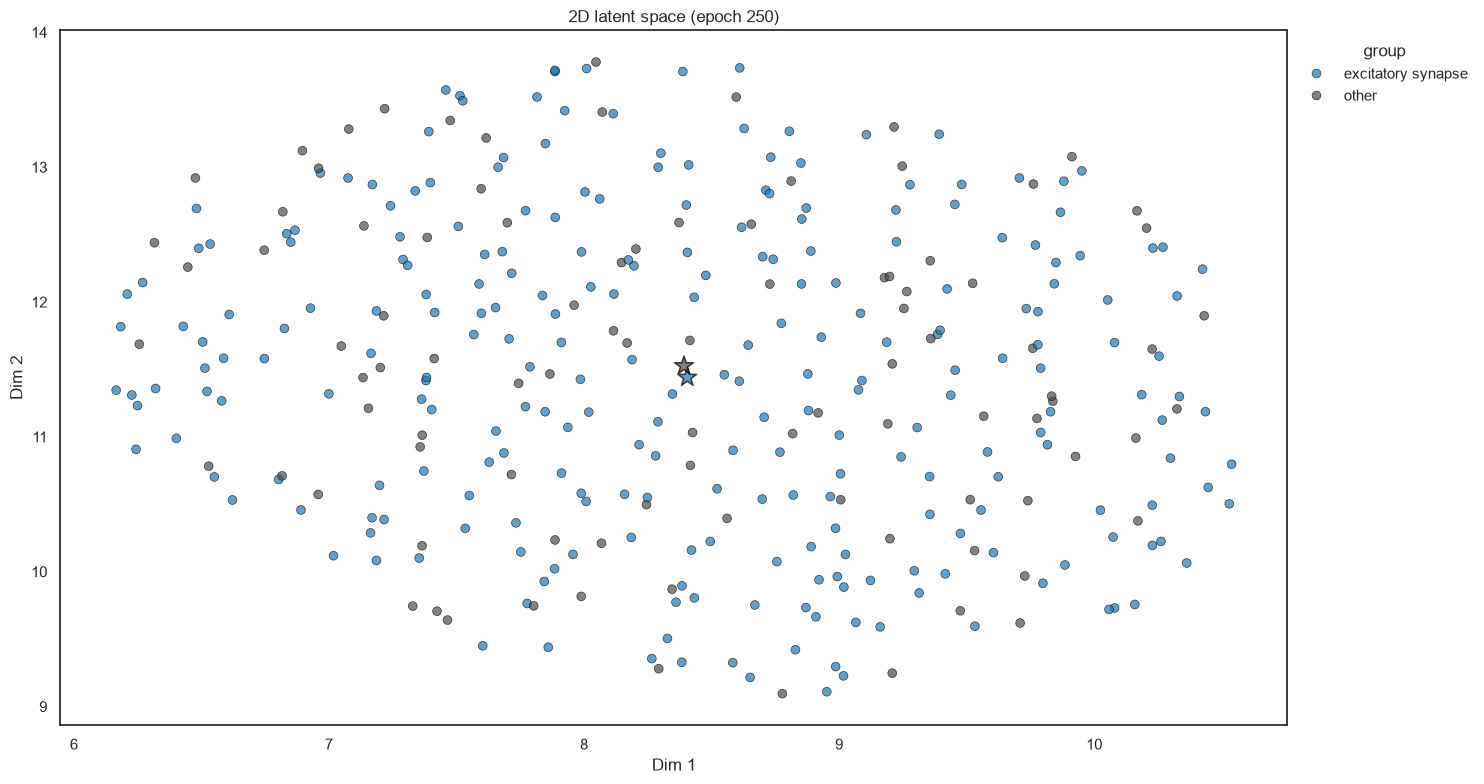

In [23]:
vis.show_latent_space(
    result=res,
    plot_type="2D-scatter",
    labels=None,
    focus_labels=["excitatory synapse"],
    param=["group"],
    epoch=None,
    split="all",
    n_downsample=None,
)

In [ ]:
vis.show_latent_space(
    result=res,
    plot_type="Ridgeline",
    labels=None,
    focus_labels=["excitatory", "inhibitory"],
    param=["group"],
    epoch=None,
    split="all",
    n_downsample=None,
)

In [ ]:
vis.plots.keys()

In [ ]:
vis.visualize(
    result=res,
    config=cfg
)

In [ ]:
vis.plots["ML_Evaluation"]


Stored train/valid latent epochs: [9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249]


,epoch,split,n_samples,n_dims,original_bins_per_dim,total_correlation_64d,coverage_original_64d,coverage_pca2,coverage_pca6
0,10,train,246,64,1,4.809634,NaN,0.471111,0.968750
1,10,valid,35,64,1,205.004048,NaN,0.520000,0.453125
2,20,train,246,64,1,14.270373,NaN,0.444444,0.968750
3,20,valid,35,64,1,213.406208,NaN,0.720000,0.421875
4,30,train,246,64,1,16.372607,NaN,0.444444,0.921875
5,30,valid,35,64,1,216.006308,NaN,0.640000,0.359375
6,40,train,246,64,1,18.768098,NaN,0.440000,0.906250
7,40,valid,35,64,1,220.084583,NaN,0.560000,0.359375
8,50,train,246,64,1,20.930126,NaN,0.395556,0.765625
9,50,valid,35,64,1,220.799837,NaN,0.520000,0.312500


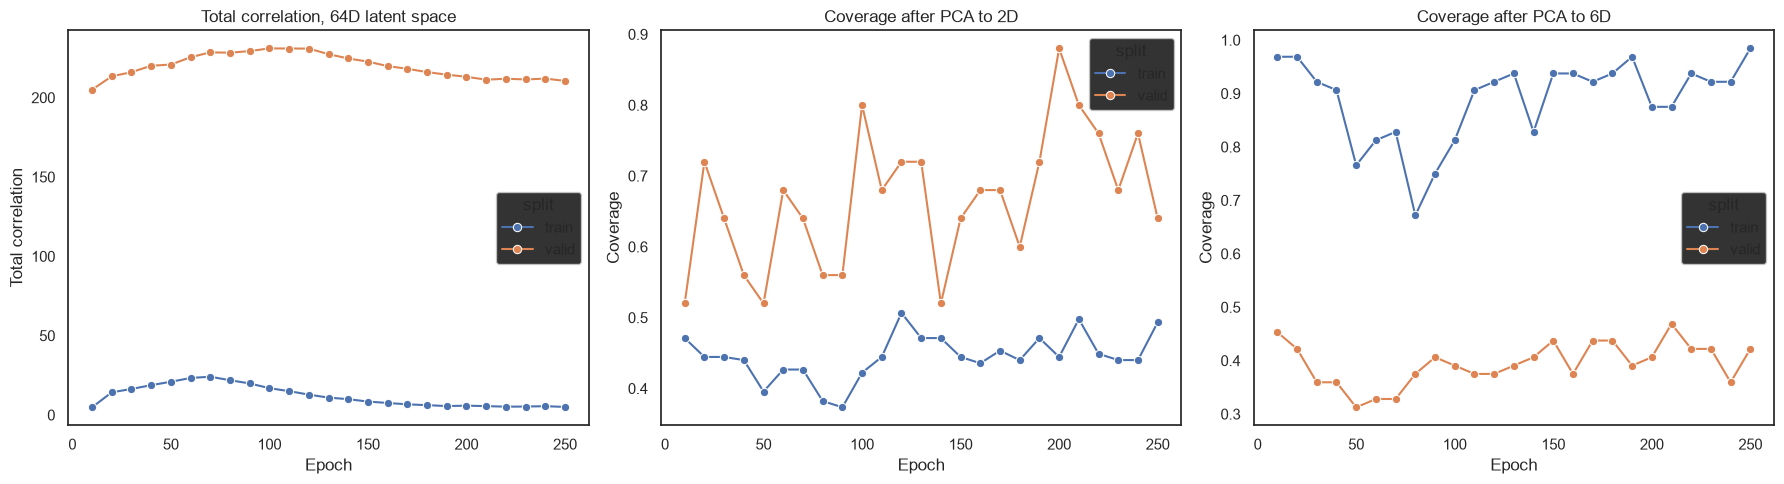

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


res = imagix3d_loaded.result
vis = imagix3d_loaded.visualizer


def safe_total_correlation(latent_df, eps=1e-6):
    """
    Robust version of AUTOENCODIX total correlation.
    Keeps only finite, non-constant numeric dimensions and regularizes covariance.
    """
    X = latent_df.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

    # remove collapsed / constant latent dimensions
    X = X.loc[:, X.var(axis=0) > eps]

    if X.shape[0] < 3 or X.shape[1] < 2:
        return np.nan

    C = np.cov(X.to_numpy(), rowvar=False)
    C = C + eps * np.eye(C.shape[0])

    diag = np.diag(C)
    sign, logdet = np.linalg.slogdet(C)

    if sign <= 0 or np.any(diag <= 0):
        return np.nan

    tc = 0.5 * (np.sum(np.log(diag)) - logdet)
    return float(tc)


def coverage_after_pca(latent_df, n_components=2, bins=None):
    """
    Coverage after PCA reduction.
    This is not the original 64D coverage; it is reduced-space coverage.
    """
    X = latent_df.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

    # remove collapsed dimensions
    X = X.loc[:, X.var(axis=0) > 1e-12]

    if X.shape[0] < 3 or X.shape[1] < 1:
        return np.nan

    k = min(n_components, X.shape[1], X.shape[0] - 1)

    X_scaled = StandardScaler().fit_transform(X)
    X_red = PCA(n_components=k, random_state=0).fit_transform(X_scaled)

    n_samples, d = X_red.shape

    if bins is None:
        bins = int(np.floor(n_samples ** (1 / d)))
        bins = max(2, bins)

    # Keep grid size from exploding
    bins = min(bins, 20)

    if bins < 2:
        return np.nan

    binned_cols = []

    for j in range(d):
        if np.nanstd(X_red[:, j]) < 1e-12:
            return np.nan

        binned = pd.cut(
            X_red[:, j],
            bins=bins,
            labels=False,
            include_lowest=True,
        )

        binned_cols.append(binned)

    occupied_cells = set(zip(*binned_cols))
    possible_cells = bins ** d

    return len(occupied_cells) / possible_cells


rows = []

stored_epochs = sorted(
    e for e in res.latentspaces._data.keys()
    if e != -1
)

print("Stored train/valid latent epochs:", stored_epochs)

for epoch in stored_epochs:
    for split in ["train", "valid"]:

        try:
            latent_df = res.get_latent_df(epoch=epoch, split=split)
        except Exception as exc:
            print(f"Skipping epoch={epoch}, split={split}: {exc}")
            continue

        if latent_df.empty:
            print(f"Skipping epoch={epoch}, split={split}: empty latent DataFrame")
            continue

        n_samples, n_dims = latent_df.shape
        original_bins_per_dim = int(np.floor(n_samples ** (1 / n_dims)))

        rows.append({
            "epoch": epoch + 1,
            "split": split,
            "n_samples": n_samples,
            "n_dims": n_dims,
            "original_bins_per_dim": original_bins_per_dim,
            "total_correlation_64d": safe_total_correlation(latent_df),
            "coverage_original_64d": np.nan,  # intentionally NaN: not meaningful here
            "coverage_pca2": coverage_after_pca(latent_df, n_components=2),
            "coverage_pca6": coverage_after_pca(latent_df, n_components=6),
        })


df_metrics = pd.DataFrame(rows)

display(df_metrics)

if df_metrics.empty:
    raise RuntimeError(
        "No train/valid latent representations were found. "
        "Check res.latentspaces._data and make sure you are using imagix3d_loaded.result."
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="total_correlation_64d",
    hue="split",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Total correlation, 64D latent space")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total correlation")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage_pca2",
    hue="split",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Coverage after PCA to 2D")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Coverage")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage_pca6",
    hue="split",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Coverage after PCA to 6D")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Coverage")

plt.tight_layout()
plt.show()

[-1, 9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249]

[9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249]

[9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249]



,epoch,split,mean_abs_pairwise_corr,max_abs_pairwise_corr,n_samples,n_latent_dims
0,10,train,0.053842,0.287740,246,64
1,10,valid,0.140830,0.553144,35,64
2,20,train,0.093494,0.896967,246,64
3,20,valid,0.171100,0.888061,35,64
4,30,train,0.080435,0.868523,246,64
5,30,valid,0.161939,0.857507,35,64
6,40,train,0.082888,0.858068,246,64
7,40,valid,0.159844,0.878187,35,64
8,50,train,0.087008,0.821991,246,64
9,50,valid,0.164121,0.827904,35,64


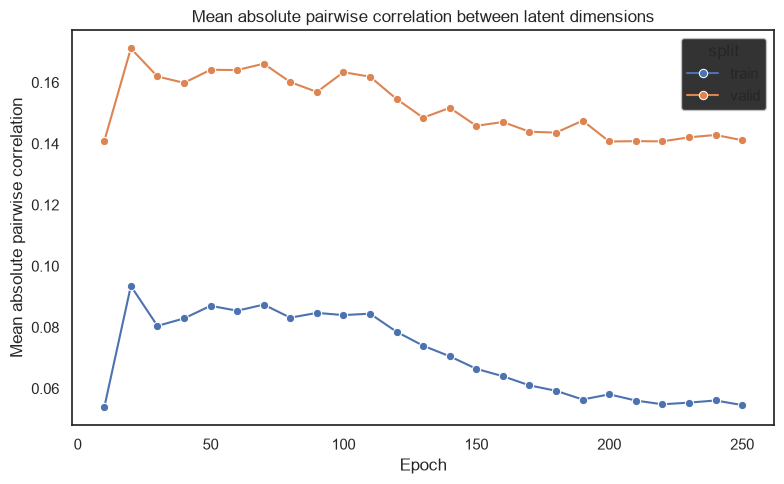

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

res = imagix3d_loaded.result
rows = []
stored_epochs = [e for e in res.latentspaces._data.keys() if e != -1]
print(stored_epochs)
print('')

for epoch in stored_epochs:
    for split in ["train", "valid"]:
        latent_df = res.get_latent_df(epoch=epoch, split=split)

        if latent_df.empty:
            continue

        X = latent_df.select_dtypes(include=[np.number])
        X = X.loc[:, X.var(axis=0) > 1e-12]

        corr = X.corr().to_numpy()

        # upper triangle (because corr matrices are symmetric), excluding diagonal (k=1)
        tri = corr[np.triu_indices_from(corr, k=1)]

        rows.append({
            "epoch": epoch + 1,
            "split": split,
            "mean_abs_pairwise_corr": np.nanmean(np.abs(tri)),
            "max_abs_pairwise_corr": np.nanmax(np.abs(tri)),
            "n_samples": X.shape[0],
            "n_latent_dims": X.shape[1],
        })

df_corr = pd.DataFrame(rows)
display(df_corr)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_corr,
    x="epoch",
    y="mean_abs_pairwise_corr",
    hue="split",
    marker="o",
)
plt.title("Mean absolute pairwise correlation between latent dimensions")
plt.xlabel("Epoch")
plt.ylabel("Mean absolute pairwise correlation")
plt.tight_layout()
plt.show()

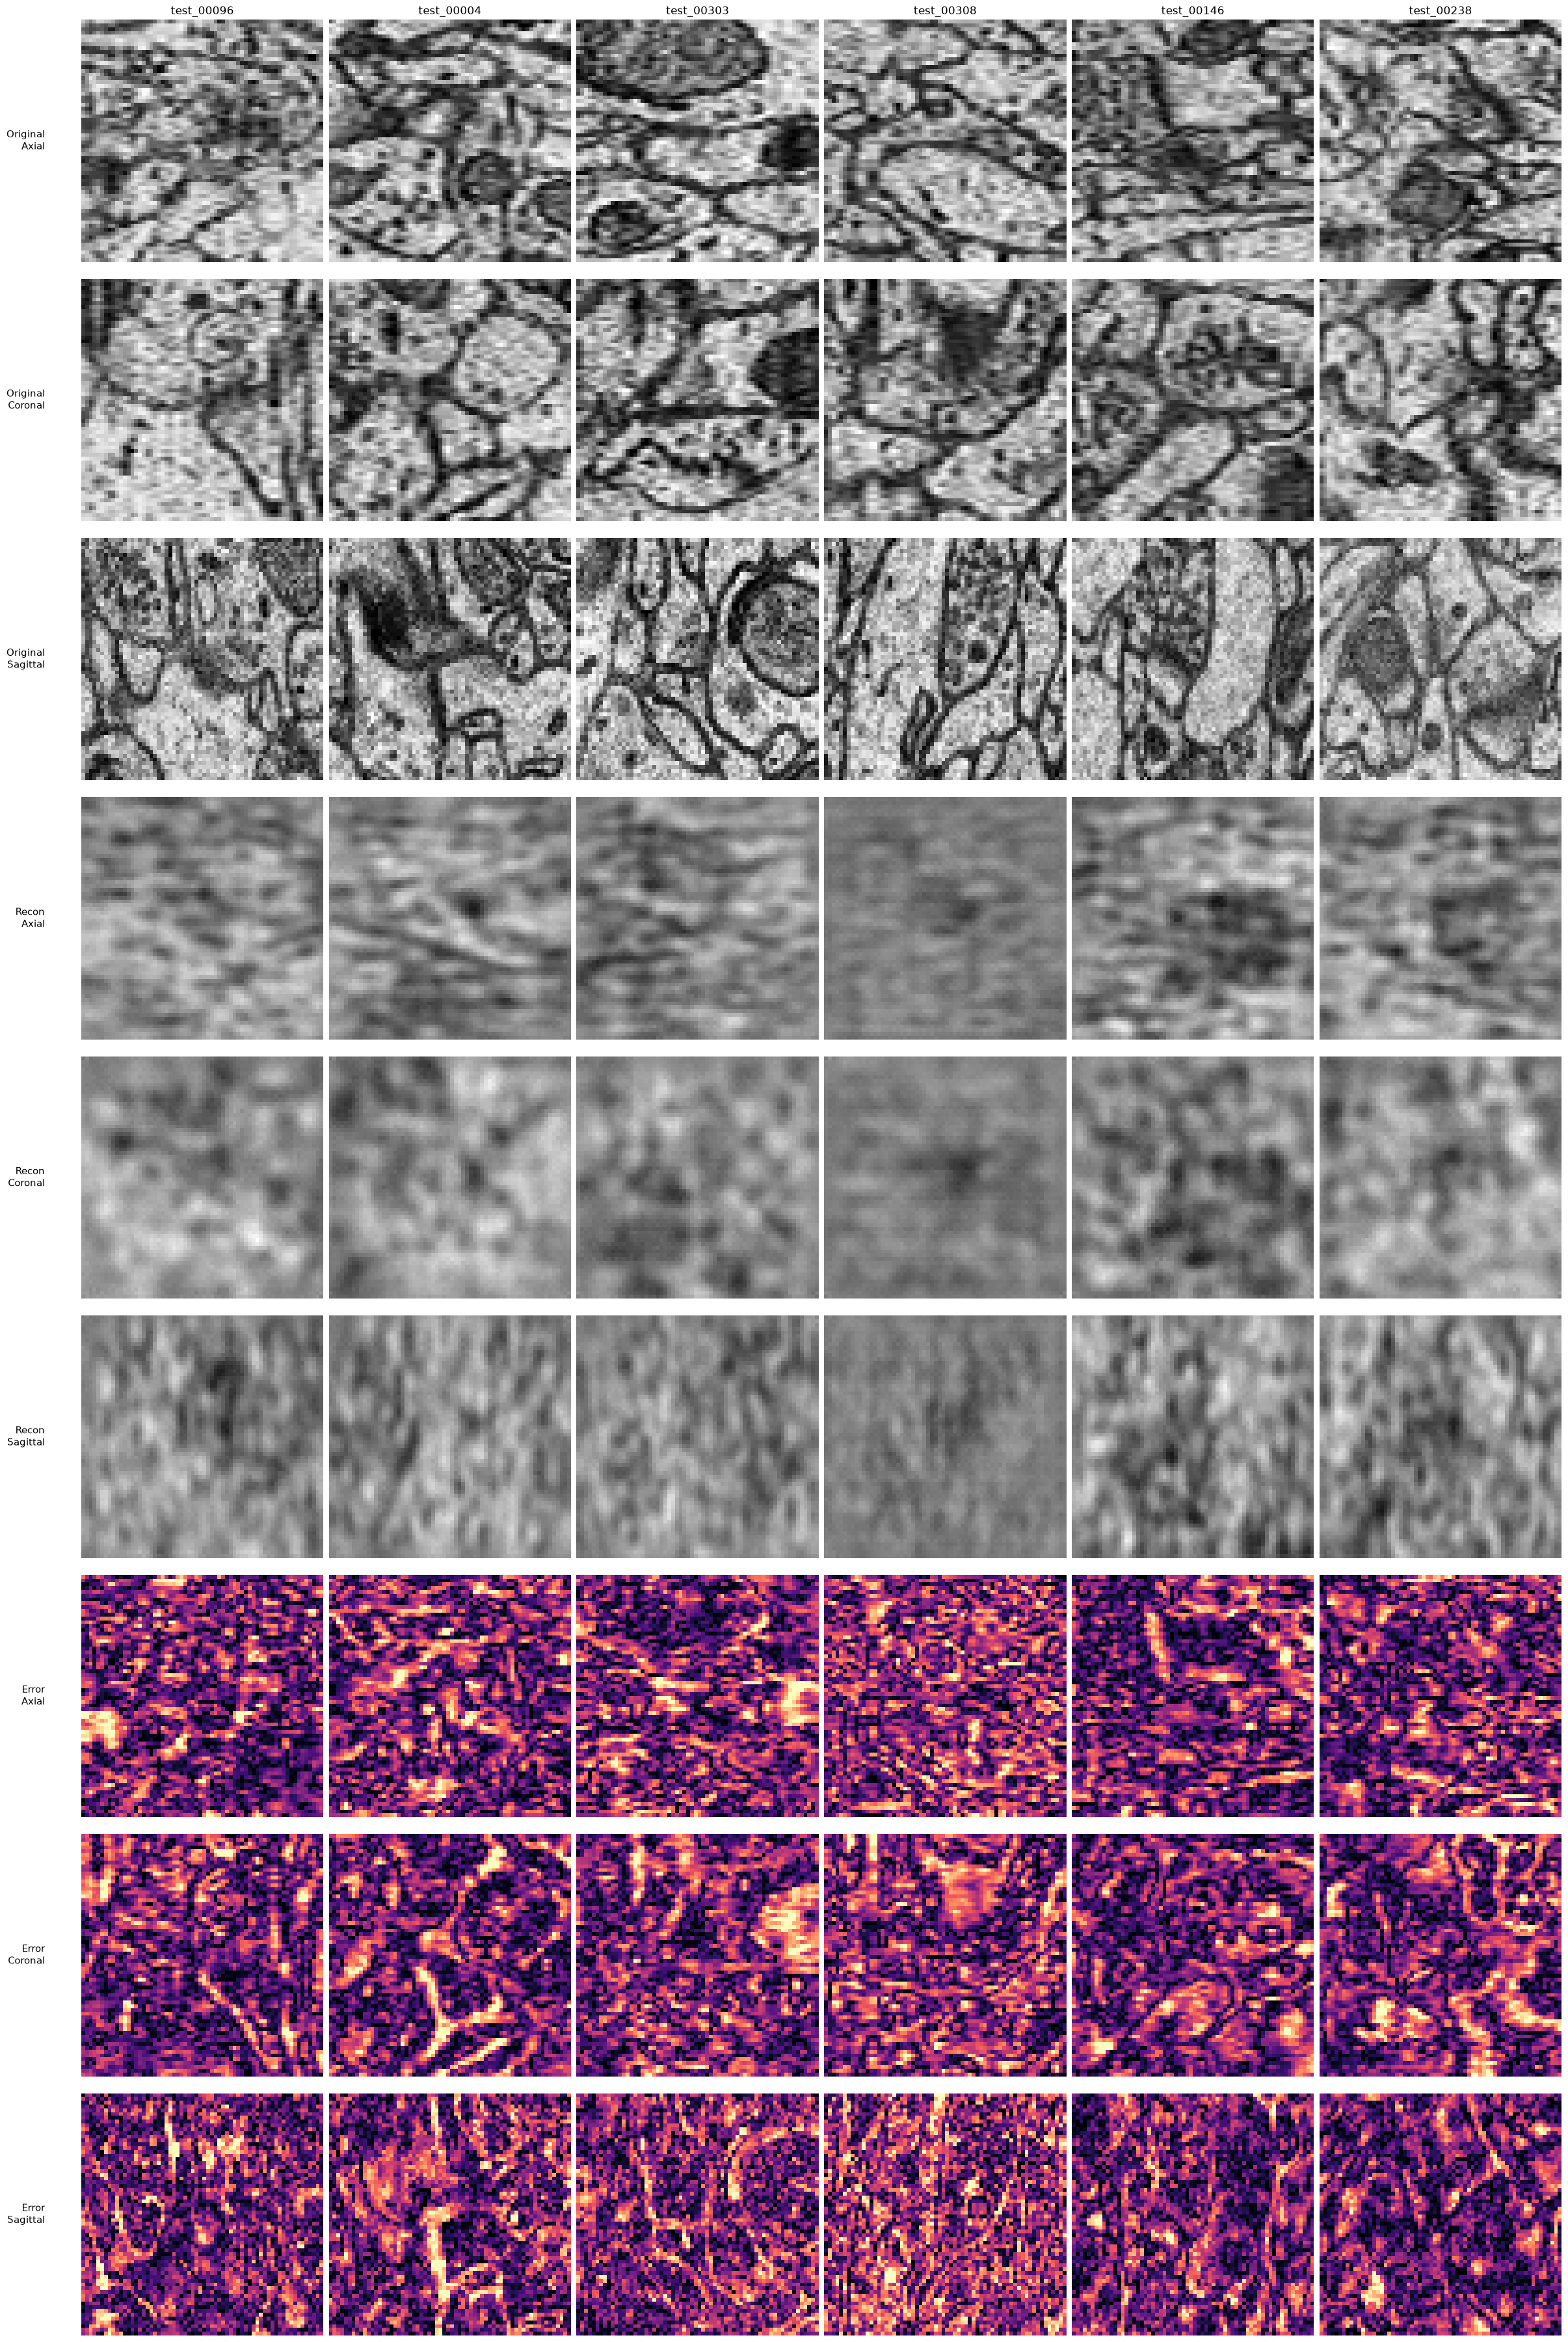


n recon ids: 71
n data ids: 71
same order: True
0 test_00004 test_00004
1 test_00293 test_00293
2 test_00059 test_00059
3 test_00070 test_00070
4 test_00308 test_00308


In [5]:
imagix3d_loaded.visualizer.show_image_recon_grid(
    result=imagix3d_loaded.result,
    n_samples=6,
    #selection="bmw",
    #metric="mse",
)